In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
df = pd.read_csv('/content/archive (5).zip')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
print("Shape:", df.shape)
print("\nColumn Info:")
df.info()
print("\nMissing values:\n", df.isnull().sum())

Shape: (9800, 18)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 

In [4]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')

# Drop rows where date conversion failed
df.dropna(subset=['Order Date'], inplace=True)

# Drop duplicates
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# Sort by date (important for time series!)
df.sort_values('Order Date', inplace=True)

print("Shape after cleaning:", df.shape)
print("Date range:", df['Order Date'].min(), "to", df['Order Date'].max())

Duplicate rows: 0
Shape after cleaning: (9800, 18)
Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00


In [5]:
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales.columns = ['Date', 'Sales']

daily_sales = daily_sales.set_index('Date').asfreq('D', fill_value=0).reset_index()

print("Daily sales shape:", daily_sales.shape)
daily_sales.head()

Daily sales shape: (1458, 2)


,Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


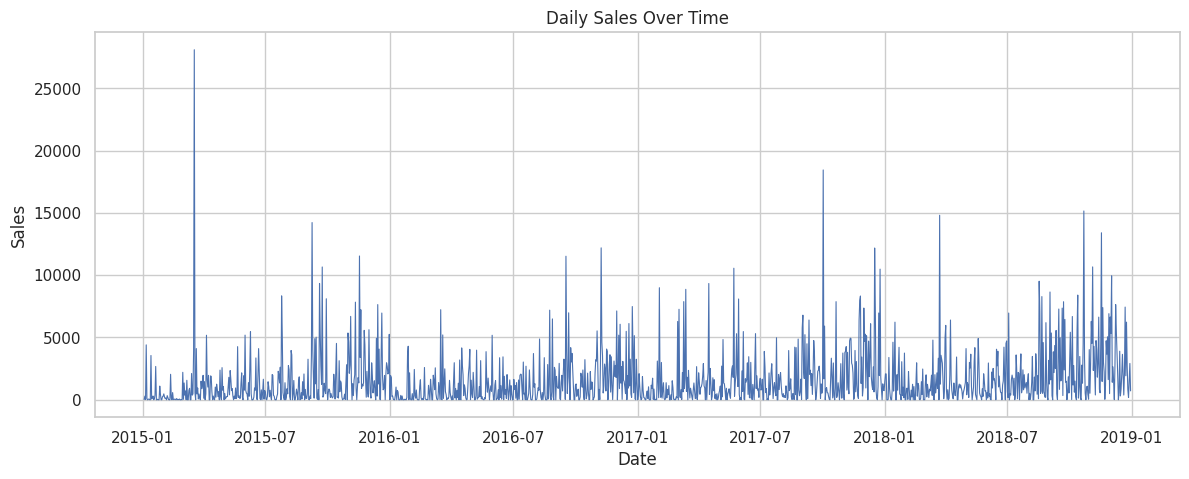

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(daily_sales['Date'], daily_sales['Sales'], linewidth=0.8)
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

/tmp/ipykernel_2303/527592443.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = daily_sales.set_index('Date')['Sales'].resample('M').sum().reset_index()


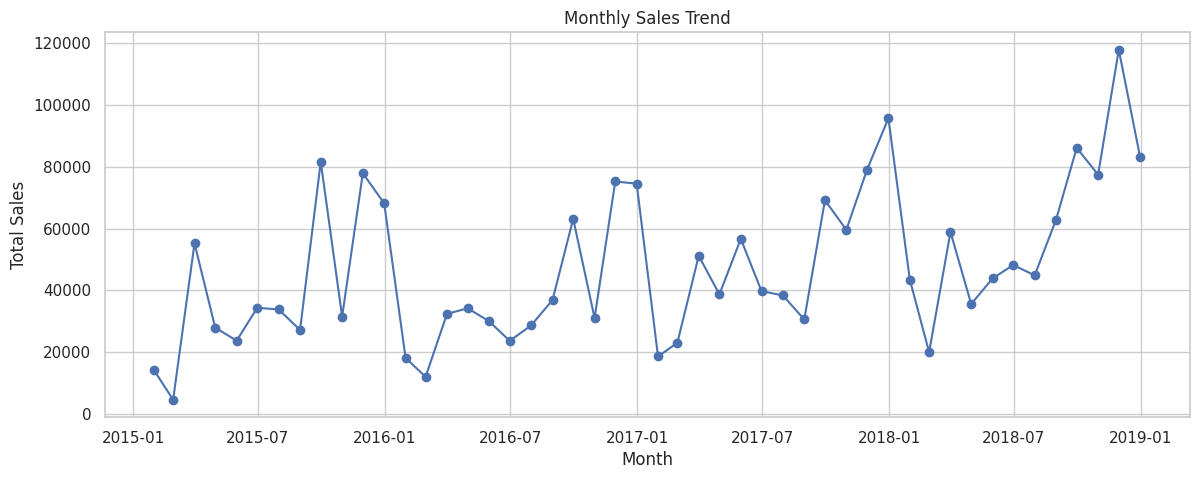

In [7]:
monthly_sales = daily_sales.set_index('Date')['Sales'].resample('M').sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Date'], monthly_sales['Sales'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

/tmp/ipykernel_2303/3481767074.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='Sales', data=monthly_sales, palette='Set2')


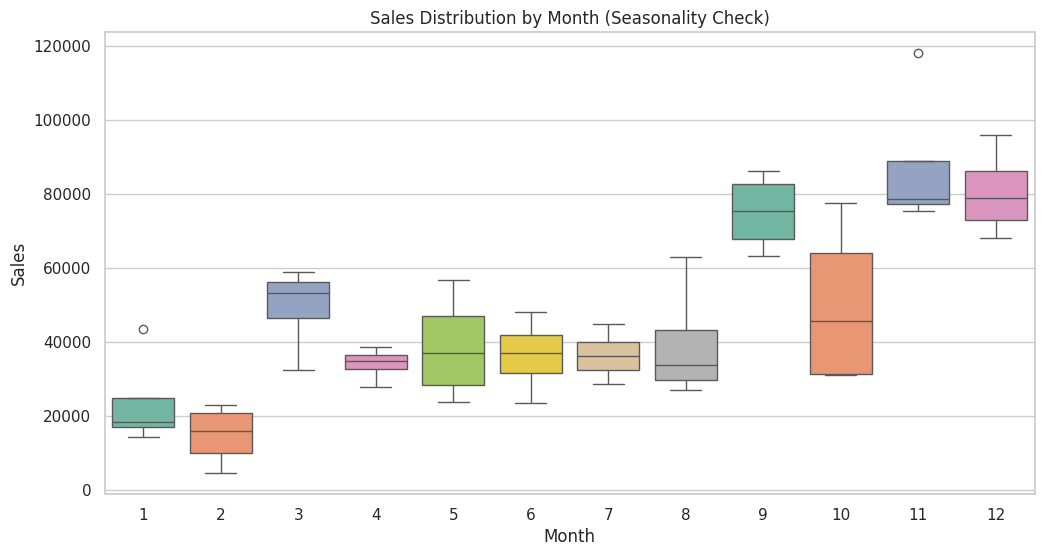

In [8]:
monthly_sales['Month'] = monthly_sales['Date'].dt.month
monthly_sales['Year'] = monthly_sales['Date'].dt.year

plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Sales', data=monthly_sales, palette='Set2')
plt.title('Sales Distribution by Month (Seasonality Check)')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

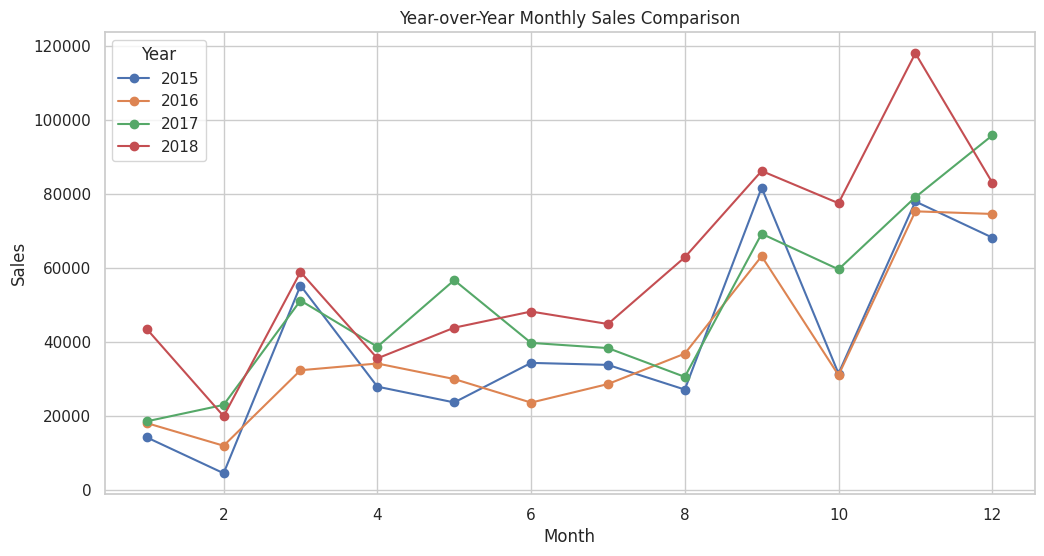

In [9]:
plt.figure(figsize=(12, 6))
for year in sorted(monthly_sales['Year'].unique()):
    subset = monthly_sales[monthly_sales['Year'] == year]
    plt.plot(subset['Month'], subset['Sales'], marker='o', label=str(year))

plt.title('Year-over-Year Monthly Sales Comparison')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.legend(title='Year')
plt.show()

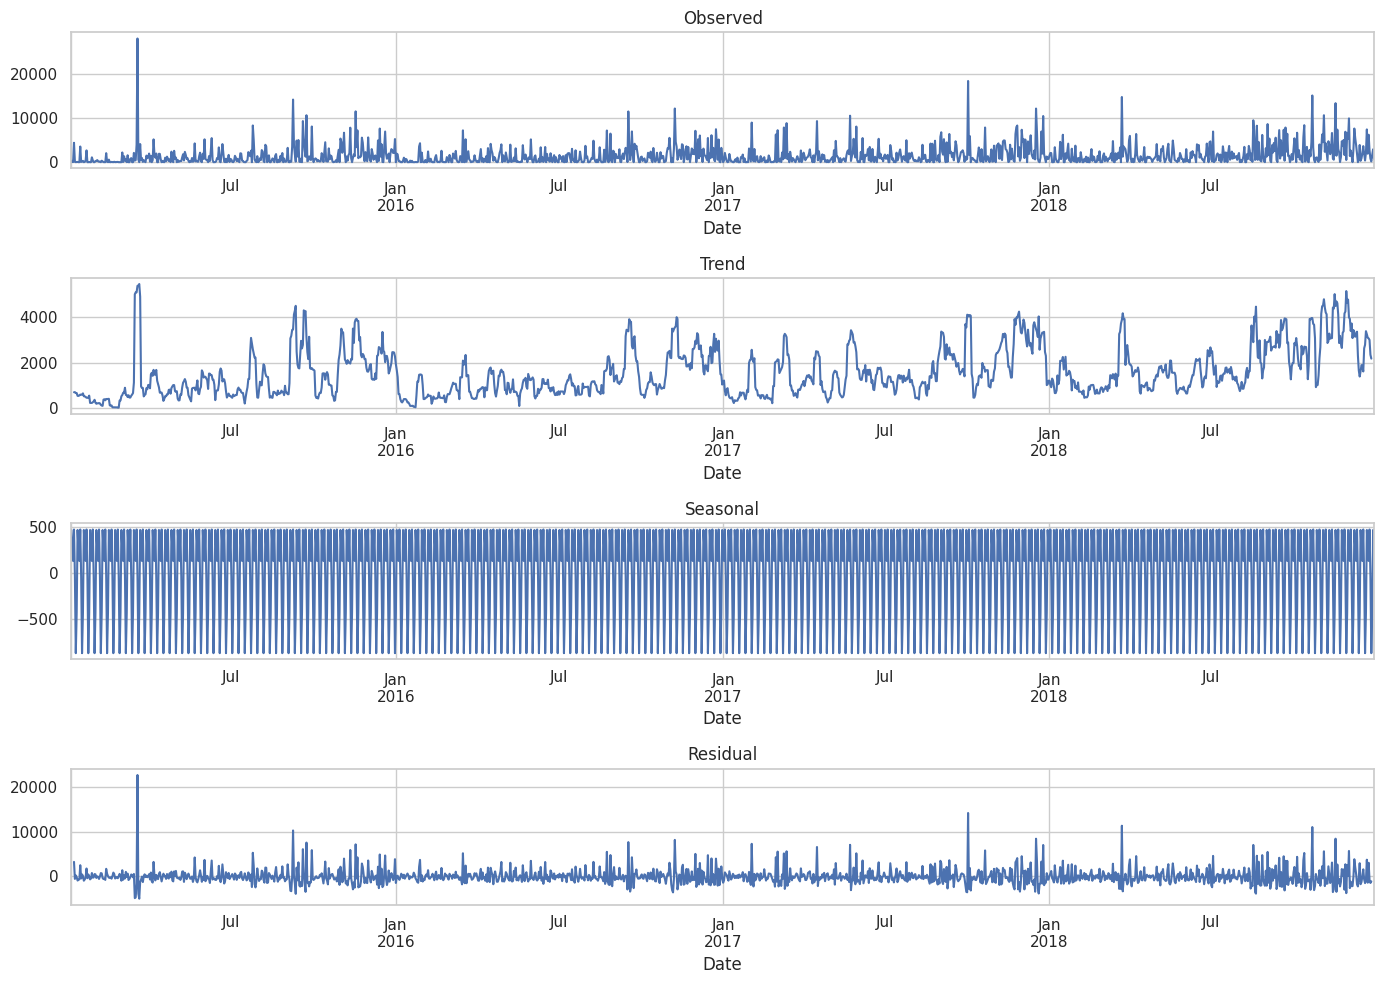

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = daily_sales.set_index('Date')['Sales']

decomposition = seasonal_decompose(ts, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

In [11]:
data = daily_sales.copy()

data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['DayOfWeek'] = data['Date'].dt.dayofweek
data['DayOfYear'] = data['Date'].dt.dayofyear
data['WeekOfYear'] = data['Date'].dt.isocalendar().week.astype(int)
data['IsWeekend'] = data['DayOfWeek'].isin([5, 6]).astype(int)
data['Quarter'] = data['Date'].dt.quarter

data.head()

,Date,Sales,Year,Month,Day,DayOfWeek,DayOfYear,WeekOfYear,IsWeekend,Quarter
0,2015-01-03,16.448,2015,1,3,5,3,1,1,1
1,2015-01-04,288.060,2015,1,4,6,4,1,1,1
2,2015-01-05,19.536,2015,1,5,0,5,2,0,1
3,2015-01-06,4407.100,2015,1,6,1,6,2,0,1
4,2015-01-07,87.158,2015,1,7,2,7,2,0,1


In [12]:
for lag in [1, 7, 14, 30]:
    data[f'Sales_lag_{lag}'] = data['Sales'].shift(lag)

data.head(35)

,Date,Sales,Year,Month,Day,DayOfWeek,DayOfYear,WeekOfYear,IsWeekend,Quarter,Sales_lag_1,Sales_lag_7,Sales_lag_14,Sales_lag_30
0,2015-01-03,16.448,2015,1,3,5,3,1,1,1,NaN,NaN,NaN,NaN
1,2015-01-04,288.060,2015,1,4,6,4,1,1,1,16.448,NaN,NaN,NaN
2,2015-01-05,19.536,2015,1,5,0,5,2,0,1,288.060,NaN,NaN,NaN
3,2015-01-06,4407.100,2015,1,6,1,6,2,0,1,19.536,NaN,NaN,NaN
4,2015-01-07,87.158,2015,1,7,2,7,2,0,1,4407.100,NaN,NaN,NaN
5,2015-01-08,0.000,2015,1,8,3,8,2,0,1,87.158,NaN,NaN,NaN
6,2015-01-09,40.544,2015,1,9,4,9,2,0,1,0.000,NaN,NaN,NaN
7,2015-01-10,54.830,2015,1,10,5,10,2,1,1,40.544,16.448,NaN,NaN
8,2015-01-11,9.940,2015,1,11,6,11,2,1,1,54.830,288.060,NaN,NaN
9,2015-01-12,0.000,2015,1,12,0,12,3,0,1,9.940,19.536,NaN,NaN


In [13]:
data['RollingMean_7'] = data['Sales'].shift(1).rolling(window=7).mean()
data['RollingMean_30'] = data['Sales'].shift(1).rolling(window=30).mean()
data['RollingStd_7'] = data['Sales'].shift(1).rolling(window=7).std()

data.dropna(inplace=True)

print("Shape after feature engineering:", data.shape)
data.head()

Shape after feature engineering: (1428, 17)


,Date,Sales,Year,Month,Day,DayOfWeek,DayOfYear,WeekOfYear,IsWeekend,Quarter,Sales_lag_1,Sales_lag_7,Sales_lag_14,Sales_lag_30,RollingMean_7,RollingMean_30,RollingStd_7
30,2015-02-02,211.646,2015,2,2,0,33,6,0,1,468.900,1097.250,378.594,16.448,361.130571,489.153567,373.119158
31,2015-02-03,97.112,2015,2,3,1,34,6,0,1,211.646,426.670,2673.870,288.060,234.615714,495.660167,184.272985
32,2015-02-04,134.384,2015,2,4,2,35,6,0,1,97.112,3.928,0.000,19.536,187.536000,489.295233,168.446888
33,2015-02-05,0.000,2015,2,5,3,36,6,0,1,134.384,0.000,0.000,4407.100,206.172571,493.123500,151.067374
34,2015-02-06,330.512,2015,2,6,4,37,6,0,1,0.000,240.500,40.080,87.158,206.172571,346.220167,151.067374


In [14]:
feature_cols = ['Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'WeekOfYear',
                 'IsWeekend', 'Quarter', 'Sales_lag_1', 'Sales_lag_7',
                 'Sales_lag_14', 'Sales_lag_30', 'RollingMean_7',
                 'RollingMean_30', 'RollingStd_7']

X = data[feature_cols]
y = data['Sales']

split_index = int(len(data) * 0.85)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
dates_test = data['Date'].iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train period:", data['Date'].iloc[0], "to", data['Date'].iloc[split_index-1])
print("Test period:", data['Date'].iloc[split_index], "to", data['Date'].iloc[-1])

Train shape: (1213, 15)
Test shape: (215, 15)
Train period: 2015-02-02 00:00:00 to 2018-05-29 00:00:00
Test period: 2018-05-30 00:00:00 to 2018-12-30 00:00:00


In [15]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [16]:
rf_model = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [17]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print(f"\n===== {name} =====")
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("MAPE:", round(mape, 2), "%")
    return mae, rmse, mape

evaluate("Linear Regression", y_test, lr_preds)
evaluate("Random Forest", y_test, rf_preds)


===== Linear Regression =====
MAE : 1838.26
RMSE: 2508.66
MAPE: 676.65 %

===== Random Forest =====
MAE : 1766.98
RMSE: 2509.79
MAPE: 525.06 %


(1766.9755841532292,
 np.float64(2509.793073685745),
 np.float64(525.057116170166))

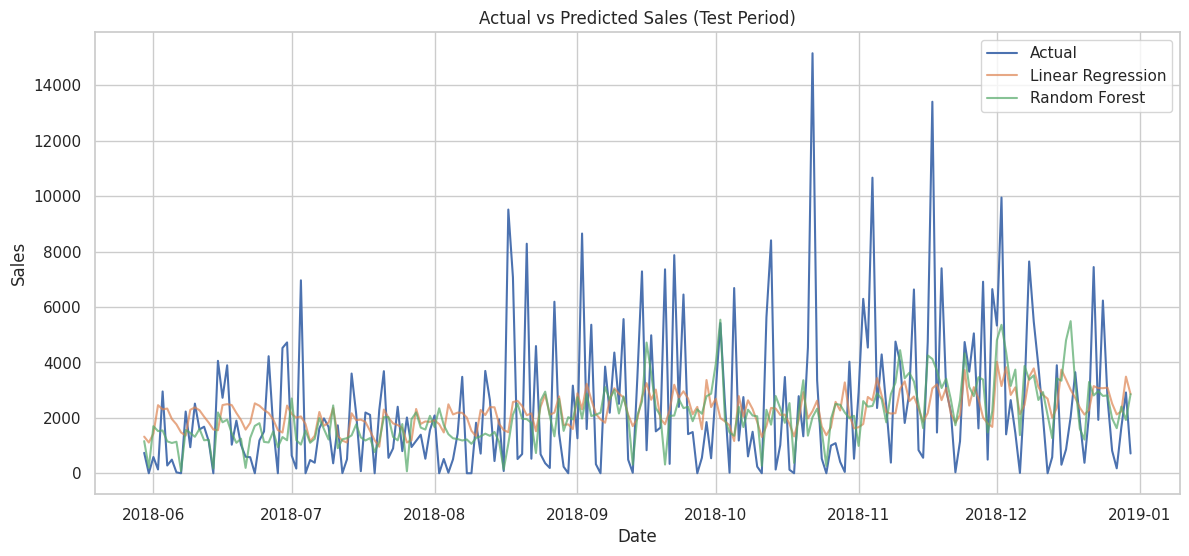

In [18]:
plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test.values, label='Actual', linewidth=1.5)
plt.plot(dates_test, lr_preds, label='Linear Regression', alpha=0.7)
plt.plot(dates_test, rf_preds, label='Random Forest', alpha=0.7)
plt.title('Actual vs Predicted Sales (Test Period)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

/tmp/ipykernel_2303/2323939862.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


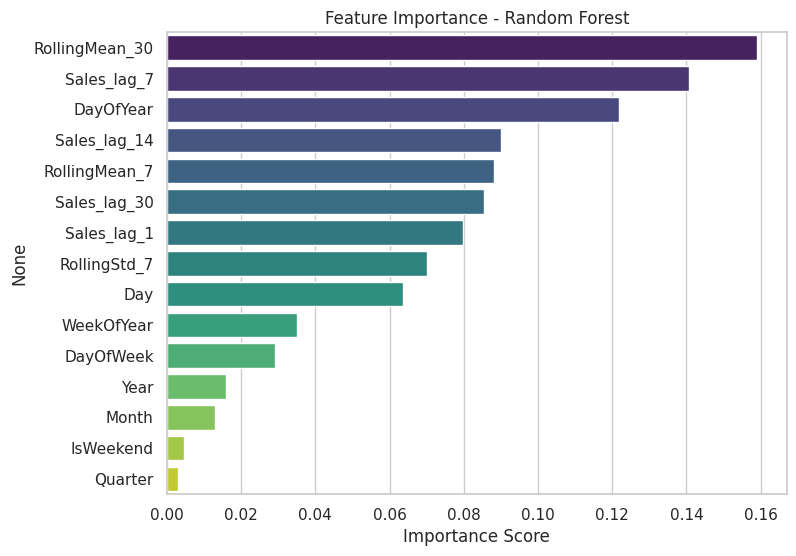

In [19]:
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.show()

In [20]:
best_model = rf_model  # change to lr_model if Linear Regression performed better

last_date = data['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30, freq='D')

history = data[['Date', 'Sales']].copy()
future_predictions = []

for date in future_dates:
    row = {
        'Year': date.year,
        'Month': date.month,
        'Day': date.day,
        'DayOfWeek': date.dayofweek,
        'DayOfYear': date.dayofyear,
        'WeekOfYear': date.isocalendar()[1],
        'IsWeekend': int(date.dayofweek in [5, 6]),
        'Quarter': date.quarter,
        'Sales_lag_1': history['Sales'].iloc[-1],
        'Sales_lag_7': history['Sales'].iloc[-7],
        'Sales_lag_14': history['Sales'].iloc[-14],
        'Sales_lag_30': history['Sales'].iloc[-30],
        'RollingMean_7': history['Sales'].iloc[-7:].mean(),
        'RollingMean_30': history['Sales'].iloc[-30:].mean(),
        'RollingStd_7': history['Sales'].iloc[-7:].std(),
    }

    X_future = pd.DataFrame([row])[feature_cols]
    pred = best_model.predict(X_future)[0]
    pred = max(pred, 0)

    future_predictions.append(pred)
    history = pd.concat([history, pd.DataFrame({'Date': [date], 'Sales': [pred]})], ignore_index=True)

forecast_df = pd.DataFrame({'Date': future_dates, 'Forecasted_Sales': future_predictions})
forecast_df.head(10)

,Date,Forecasted_Sales
0,2018-12-31,2732.244357
1,2019-01-01,3981.198593
2,2019-01-02,1445.080773
3,2019-01-03,1367.607210
4,2019-01-04,1549.741229
5,2019-01-05,1959.316270
6,2019-01-06,2341.963082
7,2019-01-07,3296.852991
8,2019-01-08,2212.953626
9,2019-01-09,1737.372908


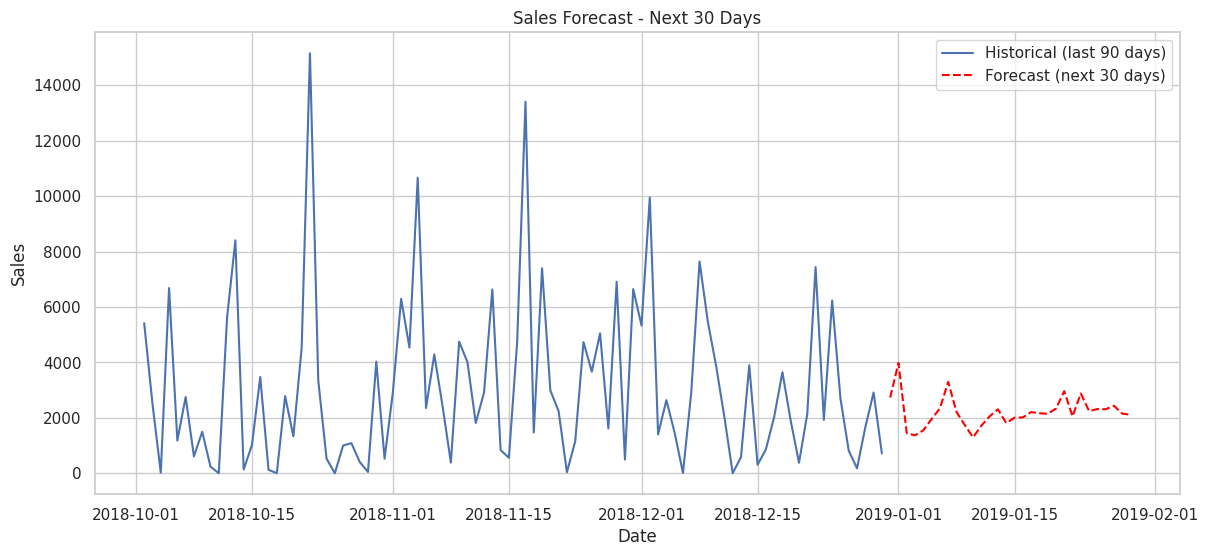

In [21]:
plt.figure(figsize=(14, 6))
plt.plot(data['Date'].iloc[-90:], data['Sales'].iloc[-90:], label='Historical (last 90 days)')
plt.plot(forecast_df['Date'], forecast_df['Forecasted_Sales'], label='Forecast (next 30 days)',
          color='red', linestyle='--')
plt.title('Sales Forecast - Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

## Key Insights & Observations

1. Sales show an upward trend over the years with periodic dips.
2. Strong seasonality exists — certain months show higher sales (holiday season).
3. Lag features (previous day/week sales) and rolling averages were the most
   important predictors, showing strong short-term momentum.
4. [Update: Random Forest / Linear Regression] performed better based on MAE/RMSE.
5. Recommendation: Use the 30-day forecast for inventory planning; increase
   stock ahead of high-season months identified in the seasonality analysis.